# PHYS 434 Lab 1

In [1]:
import numpy as np
from scipy import stats
from scipy.special import erfc
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider

# A little statistics

## 1. Gaussian

We start with 0, 1, 2, 3, and 5 sigma and calculate the probability to the left of each value. We use both `cdf()` and `erfc()` to check that they give the same result.

In [2]:
sigmas = np.array([0, 1, 2, 3, 5])

cdf_probs = stats.norm.cdf(sigmas)
cdf_erfc = 0.5 * erfc(-sigmas / np.sqrt(2))

print("sigma    CDF (SciPy)    CDF (erfc)")
for z, p1, p2 in zip(sigmas, cdf_probs, cdf_erfc):
    print(f"{z:5.0f}    {p1:.10f}    {p2:.10f}")

sigma    CDF (SciPy)    CDF (erfc)
    0    0.5000000000    0.5000000000
    1    0.8413447461    0.8413447461
    2    0.9772498681    0.9772498681
    3    0.9986501020    0.9986501020
    5    0.9999997133    0.9999997133


In [3]:
# Compare with standard z-table values rounded to five decimal places.
z_table = np.array([0.50000, 0.84134, 0.97725, 0.99865, 1.00000])
print(np.allclose(cdf_probs, z_table, atol=5e-6, rtol=0))

True


The two methods agree, and the probabilities match the z-table after rounding. Now we use `ppf()` to go from probability back to sigma.

In [4]:
known_sigmas = np.array([1, 2, 5])
known_probs = stats.norm.cdf(known_sigmas)
recovered_sigmas = stats.norm.ppf(known_probs)

print("\nLeft-tail cumulative probability -> sigma")
for p, z in zip(known_probs, recovered_sigmas):
    print(f"{p:.10f} -> {z:.6f} sigma")


Left-tail cumulative probability -> sigma
0.8413447461 -> 1.000000 sigma
0.9772498681 -> 2.000000 sigma
0.9999997133 -> 5.000000 sigma


The answers are 1, 2, and 5 sigma again, as expected.

`ppf(p)` uses the probability to the left of a value. When $p<0.5$, the answer is below the mean, so it is negative. For example, `ppf(0.158655)` is about -1.

## 2. Chi-squared distribution

A chi-squared variable is made by adding the squares of $k$ independent standard normal variables. It cannot be negative. Its PDF is

$$
f(x;k)=\frac{x^{k/2-1}e^{-x/2}}{2^{k/2}\Gamma(k/2)},\qquad x>0.
$$

We use $k=4$, so the expected mean is 4 and the variance is 8. In this case, the PDF is just

$$
f(x)=\frac{x}{4}e^{-x/2}.
$$

We generate 100,000 samples and compare their histogram with the PDF. The sample mean is 4.000 and the variance is 7.973, close to the expected values. The curve peaks at 2 and has a long tail to the right. The log scale helps us see the small values in the tail.

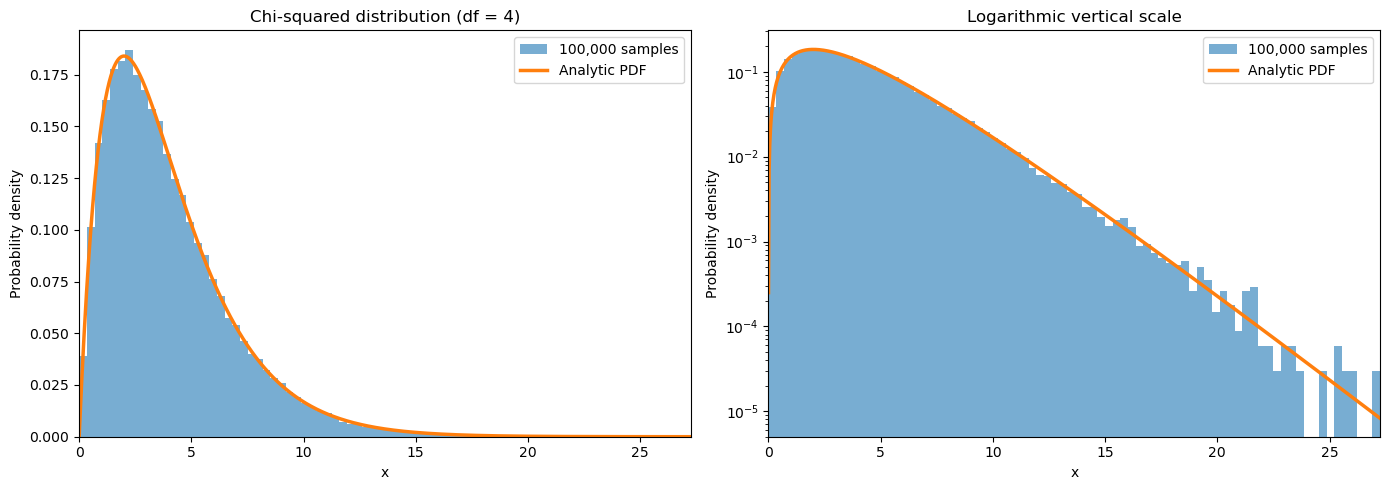

Sample mean: 4.000; theoretical mean: 4
Sample variance: 7.973; theoretical variance: 8


In [5]:
# Generate 100,000 chi-squared samples.
k = 4  # Degrees of freedom
d = stats.chi2.rvs(df=k, size=100_000, random_state=434)

# Calculate the analytic probability density.
x = np.linspace(0.001, d.max(), 1000)
f = stats.chi2.pdf(x, df=k)

# Compare the samples with the PDF on two vertical scales.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.hist(d, bins=80, density=True, alpha=0.6,
            label="100,000 samples")
    ax.plot(x, f, linewidth=2.5, label="Analytic PDF")
    ax.set_xlabel("x")
    ax.set_ylabel("Probability density")
    ax.set_xlim(0, d.max())
    ax.legend()

axes[0].set_title("Chi-squared distribution (df = 4)")
axes[1].set_title("Logarithmic vertical scale")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Sample mean: {d.mean():.3f}; theoretical mean: {k}")
print(f"Sample variance: {d.var():.3f}; theoretical variance: {2*k}")

## 3. Probability and equivalent sigma

Suppose our background follows a chi-squared distribution with $k=4$, and we measure $x=12$. We ask: **How often would background alone give 12 or more?**

We need the area to the right of 12:

$$
p=P(X\geq12)=\int_{12}^{\infty}\frac{x}{4}e^{-x/2}\,dx.
$$

We calculate this with `stats.chi2.sf()`. Then `stats.norm.isf(p)` finds a Gaussian value with the same area to its right:

$$
P(Z\geq z)=p.
$$

The probability is about 0.01735, or 1.74%, and the equivalent value is $2.112\sigma$. This tells us how often background would give a measurement this large. It does not tell us the probability that the background model is true.

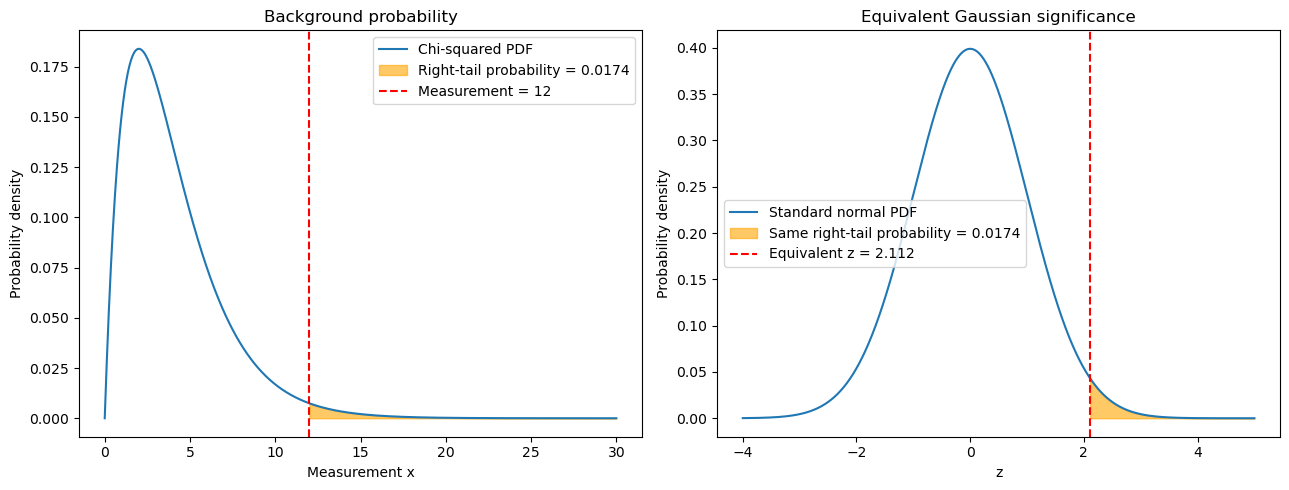

Right-tail probability: 0.017351
Equivalent significance: 2.112 sigma


In [6]:
x_obs = 12

p = stats.chi2.sf(x_obs, df=k)
z = stats.norm.isf(p)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chi-squared background distribution
x = np.linspace(0, 30, 1000)
tail_x = np.linspace(x_obs, 30, 500)

axes[0].plot(x, stats.chi2.pdf(x, df=k), label="Chi-squared PDF")
axes[0].fill_between(
    tail_x, stats.chi2.pdf(tail_x, df=k),
    color="orange", alpha=0.6, label=f"Right-tail probability = {p:.4f}"
)
axes[0].axvline(x_obs, color="red", linestyle="--",
               label=f"Measurement = {x_obs}")
axes[0].set_title("Background probability")
axes[0].set_xlabel("Measurement x")
axes[0].set_ylabel("Probability density")
axes[0].legend()

# Standard normal distribution with the same right-tail probability
g = np.linspace(-4, 5, 1000)
g_tail = np.linspace(z, 5, 500)

axes[1].plot(g, stats.norm.pdf(g), label="Standard normal PDF")
axes[1].fill_between(
    g_tail, stats.norm.pdf(g_tail),
    color="orange", alpha=0.6, label=f"Same right-tail probability = {p:.4f}"
)
axes[1].axvline(z, color="red", linestyle="--",
               label=f"Equivalent z = {z:.3f}")
axes[1].set_title("Equivalent Gaussian significance")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Probability density")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Right-tail probability: {p:.6f}")
print(f"Equivalent significance: {z:.3f} sigma")

## 4. Different measurements

Larger measurements are less common under the background model, so their probabilities go down and their sigma values go up. For example, 12 gives $2.112\sigma$, while 20 gives $3.291\sigma$.

The small measurements have negative sigma values because more than half of the background results are above them. A Gaussian value with that same right-tail probability is below zero.

Measurement    Right-tail probability    Sigma
        1.0              9.097960e-01     -1.339
        2.0              7.357589e-01     -0.630
        4.0              4.060058e-01      0.238
        6.0              1.991483e-01      0.845
        8.0              9.157819e-02      1.331
       12.0              1.735127e-02      2.112
       16.0              3.019164e-03      2.746
       20.0              4.993992e-04      3.291


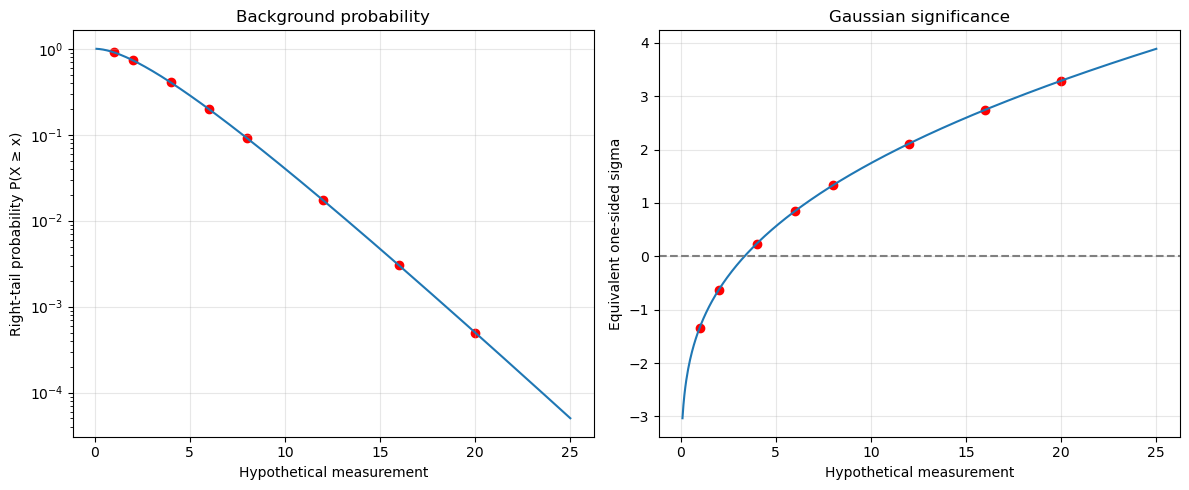

In [7]:
measurements = np.array([1, 2, 4, 6, 8, 12, 16, 20])

# Right-tail probabilities and equivalent Gaussian significance
probabilities = stats.chi2.sf(measurements, df=k)
sigmas = stats.norm.isf(probabilities)

print("Measurement    Right-tail probability    Sigma")
for value, p, z in zip(measurements, probabilities, sigmas):
    print(f"{value:11.1f}    {p:22.6e}    {z:7.3f}")

# Smooth curves for visualization
x = np.linspace(0.1, 25, 500)
p_curve = stats.chi2.sf(x, df=k)
z_curve = stats.norm.isf(p_curve)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(x, p_curve)
axes[0].scatter(measurements, probabilities, color="red")
axes[0].set_yscale("log")
axes[0].set_xlabel("Hypothetical measurement")
axes[0].set_ylabel("Right-tail probability P(X ≥ x)")
axes[0].set_title("Background probability")

axes[1].plot(x, z_curve)
axes[1].scatter(measurements, sigmas, color="red")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_xlabel("Hypothetical measurement")
axes[1].set_ylabel("Equivalent one-sided sigma")
axes[1].set_title("Gaussian significance")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Discrete distribution: binomial

The binomial distribution counts successes in $N$ independent trials with success probability $p$. The mean is $Np$ and the variance is $Np(1-p)$.

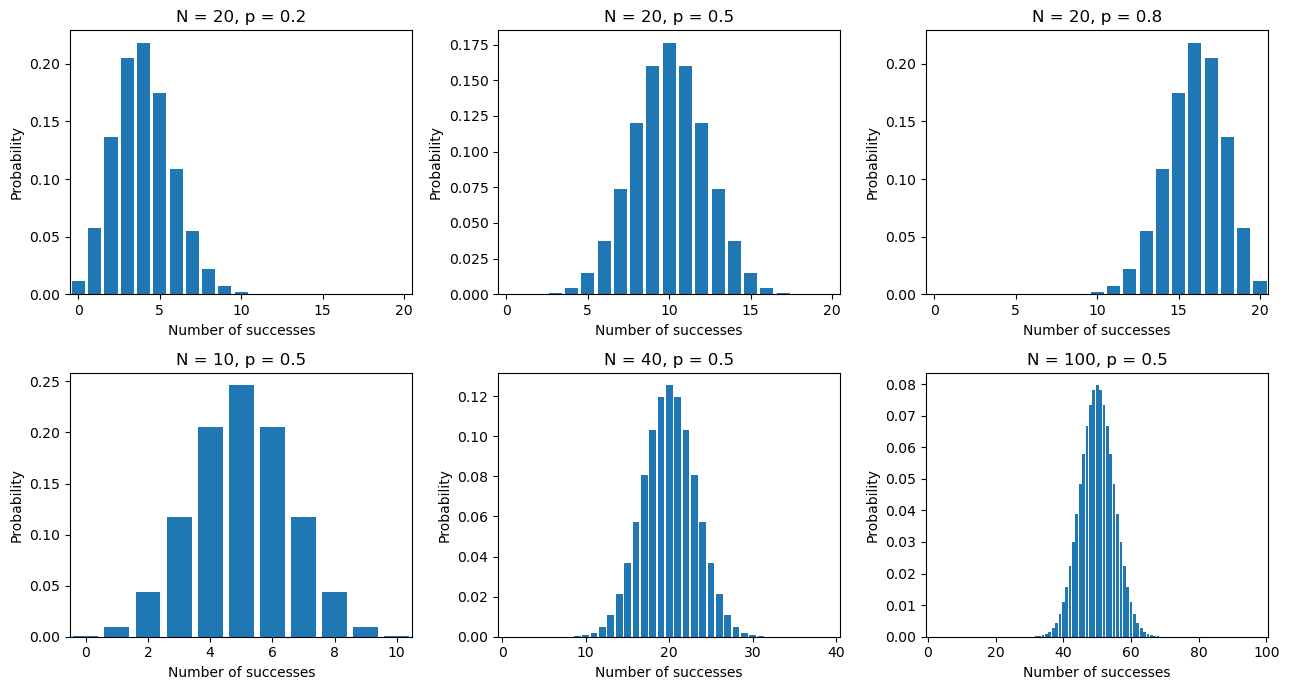

interactive(children=(IntSlider(value=100, continuous_update=False, description='N', max=1000, min=1), FloatSl…

In [8]:
parameters = [(20, 0.2), (20, 0.5), (20, 0.8),
              (10, 0.5), (40, 0.5), (100, 0.5)]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, (N, p) in zip(axes.flat, parameters):
    counts = np.arange(N + 1)
    ax.bar(counts, stats.binom.pmf(counts, N, p), width=0.8)
    ax.set_title(f"N = {N}, p = {p}")
    ax.set_xlabel("Number of successes")
    ax.set_ylabel("Probability")
    ax.set_xlim(-0.5, N + 0.5)

plt.tight_layout()
plt.show()

@interact(
    N=IntSlider(value=100, min=1, max=1000, continuous_update=False),
    p=FloatSlider(value=0.5, min=0.01, max=0.99, step=0.01,
                  continuous_update=False)
)
def plot_binomial(N, p):
    counts = np.arange(N + 1)
    mu = N * p
    sigma = np.sqrt(N * p * (1 - p))
    # Integrate the normal approximation over each integer's unit bin.
    normal_probs = (
        stats.norm.cdf(counts + 0.5, loc=mu, scale=sigma)
        - stats.norm.cdf(counts - 0.5, loc=mu, scale=sigma)
    )

    plt.figure(figsize=(8, 4))
    plt.bar(counts, stats.binom.pmf(counts, N, p), width=0.8,
            alpha=0.5, label="Binomial")
    plt.plot(counts, normal_probs, "r.-", label="Normal approximation")
    plt.xlim(max(-0.5, mu - 4*sigma), min(N + 0.5, mu + 4*sigma))
    plt.xlabel("Number of successes")
    plt.ylabel("Probability")
    plt.title(f"N = {N}, p = {p:.2f}; Np = {mu:.2f}, N(1-p) = {N*(1-p):.2f}")
    plt.legend()
    plt.show()

In [9]:
n = 20
p_background = 0.3
observed = 9

p_tail = stats.binom.sf(observed - 1, n, p_background)
z = stats.norm.isf(p_tail)

print(f"Probability of {observed} or more: {p_tail:.6f}")
print(f"Equivalent Gaussian significance: {z:.3f} sigma")

Probability of 9 or more: 0.113331
Equivalent Gaussian significance: 1.209 sigma


### C. A hypothetical measurement

Suppose we run 20 independent trials. Background has a 0.3 chance of giving a detection in each trial, and we observe 9 detections. We ask: **How often would background alone give 9 or more detections?**

$$
P(X\geq9)=\sum_{k=9}^{20}\binom{20}{k}(0.3)^k(0.7)^{20-k}.
$$

In [10]:
counts = np.arange(1, n + 1)
tails = stats.binom.sf(counts - 1, n, p_background)
sigmas = stats.norm.isf(tails)

print("Count    Right-tail probability    Sigma")
for count, tail, sigma in zip(counts, tails, sigmas):
    print(f"{count:5d}    {tail:22.6e}    {sigma:7.3f}")

Count    Right-tail probability    Sigma
    1              9.992021e-01     -3.157
    2              9.923627e-01     -2.426
    3              9.645169e-01     -1.806
    4              8.929132e-01     -1.242
    5              7.624922e-01     -0.714
    6              5.836292e-01     -0.211
    7              3.919902e-01      0.274
    8              2.277282e-01      0.746
    9              1.133315e-01      1.209
   10              4.796190e-02      1.665
   11              1.714482e-02      2.117
   12              5.138162e-03      2.566
   13              1.278880e-03      3.016
   14              2.610470e-04      3.469
   15              4.294002e-05      3.927
   16              5.550253e-06      4.395
   17              5.426947e-07      4.875
   18              3.773088e-08      5.378
   19              1.662034e-09      5.915
   20              3.486784e-11      6.521


### D. Discrete probabilities and sigma

We can observe 12 or 13 detections, but not 12.5. With the background parameters fixed, the probability and sigma therefore change in steps. Here, 12 detections give $2.566\sigma$ and 13 give $3.016\sigma$.

This means we cannot always get exactly 3 sigma. For this example, we would need at least 13 detections to reach 3 sigma.

### E. A noninteger mean

The count must be an integer, but its average does not have to be. For example, with $n=20$ and $p=0.46$, the expected mean is

$$
E[X]=np=9.2.
$$

No single experiment gives 9.2 detections. It is the average we expect over many repeated experiments.

The number of trials $n$ is an integer, but $p$ can change continuously. As $p$ changes, the mean, variance, and probabilities change continuously. The possible counts are still $0,1,\ldots,n$.